# Lazy Portfolio Panel — Viewer
Analisi comparativa dei risultati prodotti da `iq lazy-analyze`.
**Non calcola nulla** — legge i file gia' prodotti dalla CLI:
- `outputs/lazy_analysis/*/classification_*.csv`

In [1]:
%run _bootstrap_dev.ipynb


Runtime dev completato.


## §1 — Configurazione

In [2]:
from pathlib import Path
from datetime import datetime
from IPython.display import display
import plotly.express as px
import glob

ROOT        = Path().resolve().parent.parent   # investia-quant/
LAZY_DIR    = ROOT / 'outputs' / 'lazy_analysis'
EXPORT_DIR  = ROOT / 'outputs' / 'lazy_panel_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATTERN     = '*/classification_*.csv'
FILTER_PROMOTED = 'ALL'       # 'ALL' | 'PROMOTED' | 'FAILED'
SORT_BY         = 'Sharpe'    # 'Sharpe' | 'CAGR%' | 'MaxDD%' | 'DSR'
SORT_ASC        = False

print(f'Lazy dir : {LAZY_DIR}')
print(f'Export   : {EXPORT_DIR}')
print(f'Filtro   : {FILTER_PROMOTED} | Sort: {SORT_BY} asc={SORT_ASC}')

Lazy dir : /home/luca/Investia/investia-quant/outputs/lazy_analysis
Export   : /home/luca/Investia/investia-quant/outputs/lazy_panel_exports
Filtro   : ALL | Sort: Sharpe asc=False


## §2 — Classifica

In [3]:
df = load_lazy_classifications(LAZY_DIR, CSV_PATTERN, FILTER_PROMOTED, SORT_BY, SORT_ASC)
print(f'Totale    : {len(df)}')
print(f'Promossi  : {(df["Verdetto"]=="PROMOSSO").sum()}')
print(f'Rigettati : {(df["Verdetto"]=="RIGETTATO").sum()}')
my_display(df)

Totale    : 13
Promossi  : 13
Rigettati : 0


,Nome,BestFreq,CAGR%,Sharpe,MaxDD%,StabilityCV,StabilityOK,MC_A2_Sharpe_p50,MC_B_pvalue,MC_B_skill,DSR,CriteriPassati,Verdetto,_run,_file
0,greta_alt_C,Y,10.84,1.349,17.66,1.312,False,1.132,0.170,False,1.349,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
1,my_portfolio_test,W,31.12,1.337,41.50,1.277,False,1.124,0.898,False,1.337,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
2,greta_base_spy_portfolio,Y,12.56,1.322,21.50,1.331,False,1.110,0.234,False,1.322,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
3,greta_base_spy_portfolio_etf_ita,Y,12.11,1.319,21.52,0.862,False,1.107,0.120,False,1.319,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
4,greta_alt_B,Y,12.11,1.265,22.39,1.446,False,1.067,0.246,False,1.265,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
5,greta_alt_emdiv,Y,12.84,1.232,26.32,0.859,False,1.036,0.200,False,1.232,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
6,greta_alt_A,Y,11.93,1.215,22.32,1.679,False,1.021,0.282,False,1.215,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
7,greta_alt_emdiv_test,Y,13.16,1.207,24.17,1.318,False,1.023,0.310,False,1.207,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
8,robohuman_portfolio,W,26.09,1.155,46.85,1.475,False,0.950,0.070,False,1.155,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...
9,PTF_NO_OVERLAP_IEF,Q,11.49,1.093,26.24,1.158,False,0.927,0.324,False,1.093,2/3,PROMOSSO,20260617_182346,/home/luca/Investia/investia-quant/outputs/laz...


## §3 — Scatter Sharpe vs CAGR%

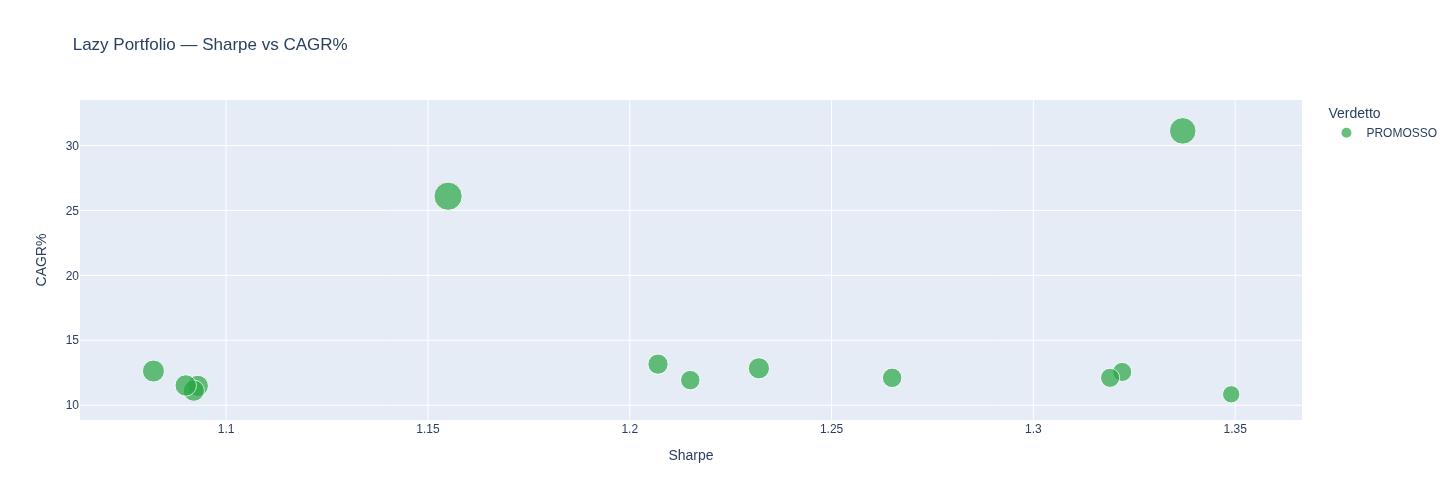

In [4]:
fig = px.scatter(
    df, x='Sharpe', y='CAGR%',
    color='Verdetto',
    color_discrete_map={'PROMOSSO': '#28a745', 'RIGETTATO': '#dc3545'},
    hover_name='Nome',
    hover_data=['MaxDD%', 'StabilityCV', 'DSR', 'BestFreq'],
    size='MaxDD%',
    title='Lazy Portfolio — Sharpe vs CAGR%'
)
fig.update_layout(height=500)
fig.show()

## §4 — Equity curve PTF promossi

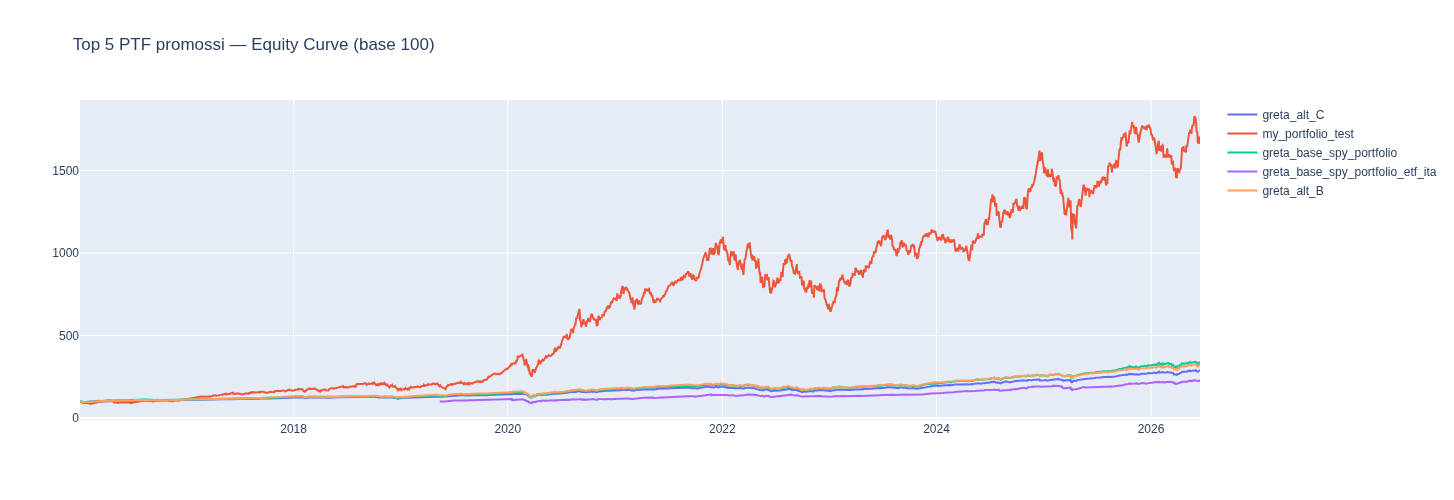

In [6]:
TOP_N = 5
plot_lazy_equity_curves(
    promoted_df=df,
    registry=L_PORTFOLIO_REGISTRY,
    top=TOP_N,
    sort_by='Sharpe',
    mode='overlay',
)

## §5 — Export promossi

In [ ]:
promoted = df[df['Verdetto'] == 'PROMOSSO'].copy()
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

csv_path = EXPORT_DIR / f'promoted_{ts}.csv'
promoted.drop(columns=['_run', '_file'], errors='ignore').to_csv(csv_path, index=False)
print(f'CSV salvato: {csv_path}')
print()

display(style_lazy_classification(
    promoted.drop(columns=['_run', '_file'], errors='ignore')
))